<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/Simple_Linear_Regression(MAE%2CMSE%2CRMSE%2Cr2_Score%2CAdjust_r2_score).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/placement (5).csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
df.shape

(200, 2)

In [ ]:
df.isnull().sum()

,0
cgpa,0
package,0


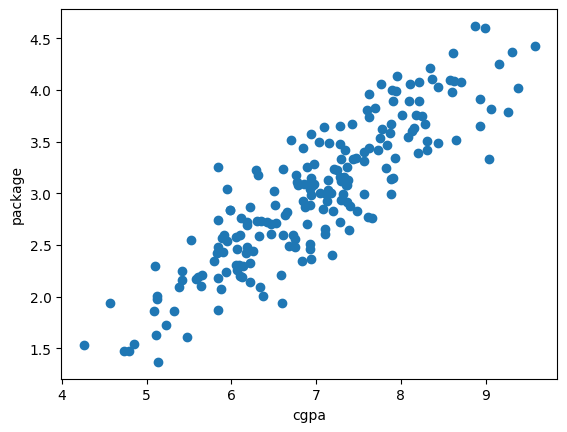

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [ ]:
X = df.drop('package', axis=1)
y = df['package']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
X_train.shape, X_test.shape

((160, 1), (40, 1))

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
y_pred

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7730984312051673

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mse

0.08417638361329656

In [ ]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
mae

0.23150985393278373

Text(0, 0.5, 'Package(in lpa)')

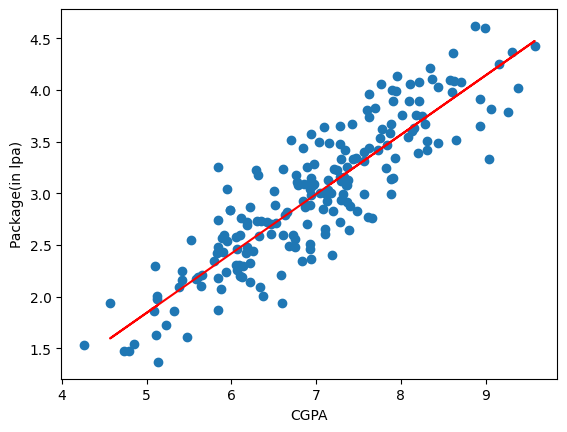

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [ ]:
df.head(3)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25


In [ ]:
# slop
m = lr.coef_
m

array([0.57425647])

In [ ]:
# intercept

c = lr.intercept_
c

np.float64(-1.0270069374542108)

In [ ]:
# Equation of line
# y = mx + c

y = m * 7.82 + c
y

array([3.46367868])

In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.7730984312051673

In [ ]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [ ]:
# Use formula or adjusted r2 score
# 1 - ((1-r2)*(n-1)/(n-k-1))

1 - ((1-r2)*(40-1)/(40-1-1))

0.7671273372895138

**Now add a random feature which is irrelivent**

In [ ]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

In [ ]:
new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1

,cgpa,random_feature,package
0,6.89,0.976614,3.26
1,5.12,0.381452,1.98
2,7.82,0.640157,3.25
3,7.42,0.141781,3.67
4,6.94,0.751870,3.57
...,...,...,...
195,6.93,0.956895,2.46
196,5.89,0.407265,2.57
197,7.21,0.778677,3.24
198,7.63,0.109033,3.96


In [ ]:
# Now again find r2_score and adjusted r2_score

Text(0, 0.5, 'Package(in lpa)')

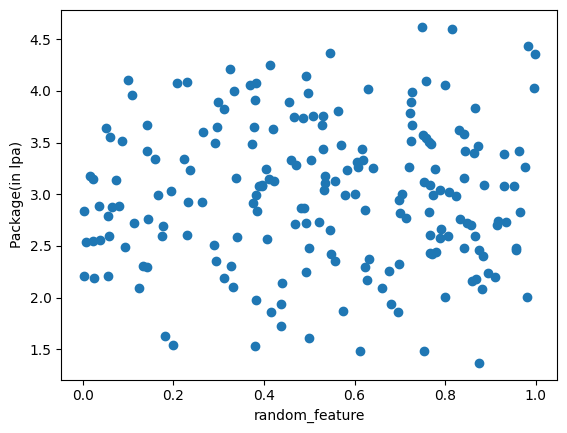

In [ ]:

plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [ ]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:

lr = LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.780212630867471


In [ ]:
# A little bit increase in r2 score

In [ ]:

1 - ((1-r2)*(40-1)/(40-1-2))

0.7683322325359829

In [ ]:
# Now again find r2_score and adjusted r2_score
# by adding relevant col iq

In [ ]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [ ]:
new_df2.sample(5)

,cgpa,iq,package
49,8.87,4.72,4.62
154,7.08,3.75,2.85
19,7.48,3.33,2.83
124,6.06,1.51,2.31
54,6.86,1.89,3.09


Text(0, 0.5, 'Package(in lpa)')

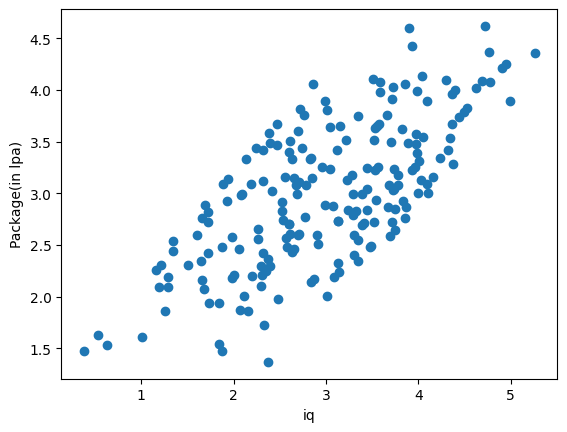

In [ ]:

plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [ ]:
np.random.randint(-100,100)

50

In [ ]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [ ]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [ ]:
# Now see more increase in r2 score by adding relivant feature

In [ ]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8166056531916688


In [ ]:

1 - ((1-r2)*(40-1)/(40-1-2))

0.8066924452560833

Text(0, 0.5, 'Package(in lpa)')

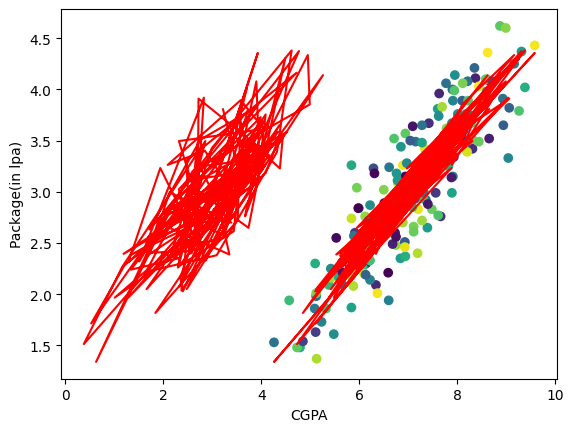

In [ ]:
plt.scatter(new_df1['cgpa'],new_df1['package'], c = new_df1['random_feature'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

Text(0, 0.5, 'Package(in lpa)')

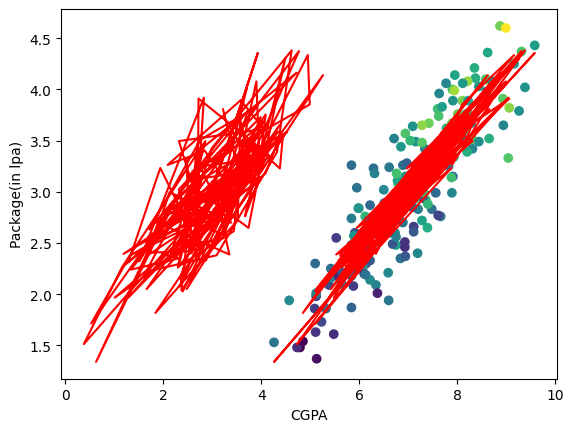

In [ ]:
plt.scatter(new_df2['cgpa'],new_df2['package'], c = new_df2['iq'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')